# Neural networks for default prediction
Run the cells from top to bottom. Both final networks have one hidden layer with eight ReLU neurons. One trains on Brier score; the other trains on asymmetric economic loss.

In [1]:
# 1. Load data
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.special import expit

DATA_DIR = Path("/Users/jessebackus/Documents/University/QF/Period 1/ML/Project")
Y_PATH = DATA_DIR / "Y_trn.csv"
if not Y_PATH.exists():
    Y_PATH = DATA_DIR / "y_trn.csv"

X_trn = pd.read_csv(DATA_DIR / "X_trn.csv").to_numpy(dtype=np.float64)
Y_trn = pd.read_csv(Y_PATH).to_numpy(dtype=np.float64).reshape(-1, 1)
X_test = pd.read_csv(DATA_DIR / "X_test.csv").to_numpy(dtype=np.float64)

assert X_trn.shape == (25000, 23)
assert Y_trn.shape == (25000, 1)
assert X_test.shape == (5000, 23)
assert np.all(np.isin(Y_trn, [0, 1]))
print(X_trn.shape, Y_trn.shape, X_test.shape)


(25000, 23) (25000, 1) (5000, 23)


In [2]:
# 2. Functions for splitting, scaling and predicting
def train_val_split(X, Y, val_fraction=0.2, seed=42):
    rng = np.random.default_rng(seed)
    indices = rng.permutation(X.shape[0])
    n_val = int(val_fraction * X.shape[0])
    return X[indices[n_val:]], Y[indices[n_val:]], X[indices[:n_val]], Y[indices[:n_val]]


def fit_standardizer(X):
    mu = X.mean(axis=0, keepdims=True)
    sigma = X.std(axis=0, keepdims=True)
    sigma[sigma == 0] = 1.0
    return mu, sigma


def apply_standardizer(X, mu, sigma):
    return (X - mu) / sigma


def initialize_parameters(n_features, n_hidden, seed=42):
    rng = np.random.default_rng(seed)
    W1 = rng.normal(0.0, np.sqrt(2 / n_features), size=(n_features, n_hidden))
    b1 = np.zeros((1, n_hidden))
    W2 = rng.normal(0.0, np.sqrt(2 / n_hidden), size=(n_hidden, 1))
    b2 = np.zeros((1, 1))
    return W1, b1, W2, b2


def predict_neural_network(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    h = np.maximum(0, z1)
    z2 = h @ W2 + b2
    return expit(z2)


def brier_score(Y, p):
    return float(np.mean((Y - p) ** 2))


def brier_score_weighted(Y, p):
    weights = np.where(Y == 1, 3.0, 1.0)
    return float(np.mean(weights * (Y - p) ** 2))


In [3]:
# 3. Train the network with mini-batches
def train_neural_network_minibatch(
    X, Y, W1, b1, W2, b2, eta=0.01, decay=0.0,
    iterations=1000, batch_size=256, weight_default=1.0, seed=42
):
    rng = np.random.default_rng(seed)
    n = X.shape[0]

    for epoch in range(iterations):
        eta_epoch = eta / (1 + decay * epoch)
        indices = rng.permutation(n)

        for start in range(0, n, batch_size):
            batch_idx = indices[start:start + batch_size]
            X_batch = X[batch_idx]
            Y_batch = Y[batch_idx]
            m = X_batch.shape[0]

            z1 = X_batch @ W1 + b1
            h = np.maximum(0, z1)
            z2 = h @ W2 + b2
            p = expit(z2)

            # Defaults get weight 3 in the economic-loss model.
            weights_batch = np.where(Y_batch == 1, weight_default, 1.0)
            dz2 = 2 * weights_batch * (p - Y_batch) * p * (1 - p) / m

            gradient_W2 = h.T @ dz2
            gradient_b2 = np.sum(dz2, axis=0, keepdims=True)
            relu_derivative = (z1 > 0).astype(float)
            dz1 = (dz2 @ W2.T) * relu_derivative
            gradient_W1 = X_batch.T @ dz1
            gradient_b1 = np.sum(dz1, axis=0, keepdims=True)

            W1 -= eta_epoch * gradient_W1
            b1 -= eta_epoch * gradient_b1
            W2 -= eta_epoch * gradient_W2
            b2 -= eta_epoch * gradient_b2

    return W1, b1, W2, b2


def train_brier_network(X, Y, W1, b1, W2, b2, eta, decay, iterations, batch_size, seed=42):
    return train_neural_network_minibatch(
        X, Y, W1, b1, W2, b2, eta, decay, iterations, batch_size, 1.0, seed
    )


def train_economic_network(X, Y, W1, b1, W2, b2, eta, decay, iterations, batch_size, seed=42):
    return train_neural_network_minibatch(
        X, Y, W1, b1, W2, b2, eta, decay, iterations, batch_size, 3.0, seed
    )


In [4]:
# 4. Make the validation set and choose the values to try
X_fit_raw, Y_fit, X_val_raw, Y_val = train_val_split(
    X_trn, Y_trn, val_fraction=0.2, seed=42
)
mu_val, sigma_val = fit_standardizer(X_fit_raw)
X_fit = apply_standardizer(X_fit_raw, mu_val, sigma_val)
X_val = apply_standardizer(X_val_raw, mu_val, sigma_val)

eta_grid = [1.0, 0.3, 0.1, 0.03, 0.01]
decay_grid = [0.0, 0.001, 0.003, 0.01]
n_hidden = 8
batch_size_grid = [128, 256, 512]
iterations = 1000


In [5]:
# 5. Try the learning rates, batch sizes and decay values
results = []
best_brier = None

for batch_size in batch_size_grid:
    for eta in eta_grid:
        for decay in decay_grid:
            W1, b1, W2, b2 = initialize_parameters(X_fit.shape[1], n_hidden, seed=42)
            W1, b1, W2, b2 = train_brier_network(
                X_fit, Y_fit, W1, b1, W2, b2, eta=eta, decay=decay,
                iterations=iterations, batch_size=batch_size, seed=42
            )
            p_val = predict_neural_network(X_val, W1, b1, W2, b2)
            score = brier_score(Y_val, p_val)
            candidate = {
                "objective": "brier", "n_hidden": n_hidden,
                "batch_size": batch_size, "eta": eta,
                "decay": decay, "validation_score": score,
            }
            results.append(candidate)
            if best_brier is None or score < best_brier["validation_score"]:
                best_brier = candidate.copy()
                best_brier["parameters"] = (W1, b1, W2, b2)

print("brier", best_brier["validation_score"], flush=True)
best_economic = None

for batch_size in batch_size_grid:
    for eta in eta_grid:
        for decay in decay_grid:
            W1, b1, W2, b2 = initialize_parameters(X_fit.shape[1], n_hidden, seed=42)
            W1, b1, W2, b2 = train_economic_network(
                X_fit, Y_fit, W1, b1, W2, b2, eta=eta, decay=decay,
                iterations=iterations, batch_size=batch_size, seed=42
            )
            p_val = predict_neural_network(X_val, W1, b1, W2, b2)
            score = brier_score_weighted(Y_val, p_val)
            candidate = {
                "objective": "economic", "n_hidden": n_hidden,
                "batch_size": batch_size, "eta": eta,
                "decay": decay, "validation_score": score,
            }
            results.append(candidate)
            if best_economic is None or score < best_economic["validation_score"]:
                best_economic = candidate.copy()
                best_economic["parameters"] = (W1, b1, W2, b2)

print("economic", best_economic["validation_score"], flush=True)
print("Hidden neurons in both models:", n_hidden)
brier_summary = best_brier.copy()
brier_summary.pop("parameters")
economic_summary = best_economic.copy()
economic_summary.pop("parameters")
print("Brier:", brier_summary)
print("Economic:", economic_summary)


brier 0.13559502765680737
economic 0.2709999874086219
Hidden neurons in both models: 8
Brier: {'objective': 'brier', 'n_hidden': 8, 'batch_size': 128, 'eta': 0.1, 'decay': 0.001, 'validation_score': 0.13559502765680737}
Economic: {'objective': 'economic', 'n_hidden': 8, 'batch_size': 512, 'eta': 0.1, 'decay': 0.001, 'validation_score': 0.2709999874086219}


In [6]:
# 6. Evaluate both fitted networks with both losses
W1, b1, W2, b2 = best_brier["parameters"]
p_val_brier = predict_neural_network(X_val, W1, b1, W2, b2)
W1, b1, W2, b2 = best_economic["parameters"]
p_val_economic = predict_neural_network(X_val, W1, b1, W2, b2)

validation_scores = pd.DataFrame(
    {
        "Brier score": [
            brier_score(Y_val, p_val_brier),
            brier_score(Y_val, p_val_economic),
        ],
        "Economic loss": [
            brier_score_weighted(Y_val, p_val_brier),
            brier_score_weighted(Y_val, p_val_economic),
        ],
    },
    index=["Brier-trained", "Economic-trained"],
)
print(validation_scores.to_string(float_format=lambda value: f"{value:.6f}"))

for label, p in (("Brier-trained", p_val_brier),
                 ("Economic-trained", p_val_economic)):
    error = (Y_val - p) ** 2
    print(
        f"{label}: mean={p.mean():.4f}, median={np.median(p):.4f}, "
        f"default MSE={error[Y_val == 1].mean():.4f}, "
        f"non-default MSE={error[Y_val == 0].mean():.4f}"
    )


                  Brier score  Economic loss
Brier-trained        0.135595       0.323569
Economic-trained     0.170896       0.271000
Brier-trained: mean=0.2218, median=0.1456, default MSE=0.4292, non-default MSE=0.0533
Economic-trained: mean=0.3953, median=0.3437, default MSE=0.2285, non-default MSE=0.1547


In [7]:
# 7. Train on all labelled data and save the test predictions
mu_final, sigma_final = fit_standardizer(X_trn)
X_trn_scaled = apply_standardizer(X_trn, mu_final, sigma_final)
X_test_scaled = apply_standardizer(X_test, mu_final, sigma_final)

W1, b1, W2, b2 = initialize_parameters(X_trn.shape[1], n_hidden, seed=42)
final_brier = train_brier_network(
    X_trn_scaled, Y_trn, W1, b1, W2, b2,
    eta=best_brier["eta"], decay=best_brier["decay"],
    iterations=iterations, batch_size=best_brier["batch_size"], seed=42,
)
W1, b1, W2, b2 = initialize_parameters(X_trn.shape[1], n_hidden, seed=42)
final_economic = train_economic_network(
    X_trn_scaled, Y_trn, W1, b1, W2, b2,
    eta=best_economic["eta"], decay=best_economic["decay"],
    iterations=iterations, batch_size=best_economic["batch_size"], seed=42,
)

W1, b1, W2, b2 = final_brier
p_test_brier = predict_neural_network(X_test_scaled, W1, b1, W2, b2)
W1, b1, W2, b2 = final_economic
p_test_economic = predict_neural_network(X_test_scaled, W1, b1, W2, b2)
predictions = np.column_stack((p_test_brier.ravel(), p_test_economic.ravel()))

assert predictions.shape == (X_test.shape[0], 2)
assert np.all(np.isfinite(predictions))
assert np.all((predictions >= 0) & (predictions <= 1))

output_path = Path.cwd() / "predictions.npy"
np.save(output_path, predictions)
assert np.array_equal(np.load(output_path), predictions)
print("Saved:", output_path, predictions.shape)


Saved: /Users/jessebackus/Documents/University/QF/Period 1/ML/Project/predictions.npy (5000, 2)


In [8]:
# 8. Look at the validation predictions in more detail
summary = []
y = Y_val.ravel()
print("Default rate in validation set:", y.mean())

for name, predictions_val in [("Brier", p_val_brier), ("Economic", p_val_economic)]:
    p = predictions_val.ravel()
    squared_errors = (y - p) ** 2
    summary.append({
        "Model": name,
        "Mean": p.mean(),
        "Minimum": p.min(),
        "5th percentile": np.quantile(p, 0.05),
        "Median": np.median(p),
        "95th percentile": np.quantile(p, 0.95),
        "Maximum": p.max(),
        "Share below 0.01": np.mean(p < 0.01),
        "Share above 0.99": np.mean(p > 0.99),
        "Mean for defaults": p[y == 1].mean(),
        "Mean for non-defaults": p[y == 0].mean(),
        "MSE for defaults": squared_errors[y == 1].mean(),
        "MSE for non-defaults": squared_errors[y == 0].mean(),
    })

validation_distribution = pd.DataFrame(summary).set_index("Model")
print(validation_distribution.T.to_string(float_format=lambda x: f"{x:.6f}"))


Default rate in validation set: 0.219
Model                    Brier  Economic
Mean                  0.221757  0.395257
Minimum               0.000000  0.000001
5th percentile        0.028218  0.067741
Median                0.145559  0.343689
95th percentile       0.709632  0.902396
Maximum               0.999692  0.999958
Share below 0.01      0.016800  0.008200
Share above 0.99      0.001000  0.007200
Mean for defaults     0.399610  0.600217
Mean for non-defaults 0.171886  0.337784
MSE for defaults      0.429165  0.228547
MSE for non-defaults  0.053275  0.154731


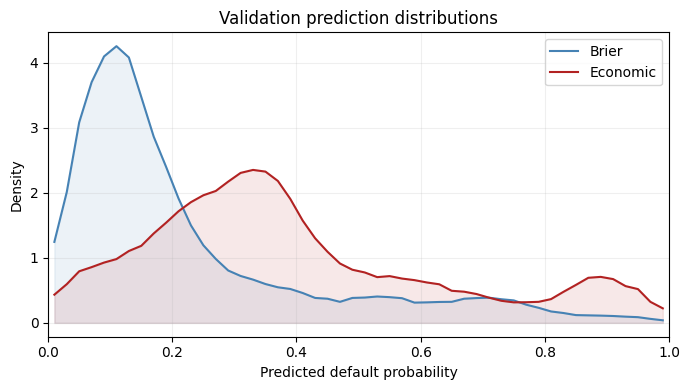

Saved: /Users/jessebackus/Documents/University/QF/Period 1/ML/Project/download.png


In [ ]:
# 9. Plot the validation predictions
import matplotlib.pyplot as plt

bins = np.linspace(0, 1, 51)
centers = (bins[:-1] + bins[1:]) / 2
fig, ax = plt.subplots(figsize=(7, 4))

for name, p, color in [
    ("Brier", p_val_brier, "steelblue"),
    ("Economic", p_val_economic, "firebrick"),
]:
    density, _ = np.histogram(p.ravel(), bins=bins, density=True)
    smooth = np.convolve(density, np.ones(5) / 5, mode="same")
    ax.plot(centers, smooth, label=name, color=color)
    ax.fill_between(centers, smooth, color=color, alpha=0.1)

ax.set(title="Validation prediction distributions",
       xlabel="Predicted default probability", ylabel="Density",
       xlim=(0, 1))
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
figure_path = DATA_DIR / "download.png"
fig.savefig(figure_path, dpi=200)
plt.show()
print("Saved:", figure_path)
